In [1]:
# ================================
# GPU SAFE SETUP (NO XLA CRASH)
# ================================
import os

# Disable XLA (fixes LSTM JIT crash)
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
# Optional: reduce TF log noise
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
tf.config.optimizer.set_jit(False)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [3]:
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("✅ GPU detected:", gpus)
    
    # Enable memory growth (prevents CUDA OOM errors)
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("❌ No GPU detected — running on CPU")

TensorFlow version: 2.12.0
❌ No GPU detected — running on CPU


2026-02-24 15:13:56.938723: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [4]:
train_df= pd.read_csv('PubMed_200k_RCT/train.csv')
dev_df = pd.read_csv('PubMed_200k_RCT/dev.csv')
test_df = pd.read_csv('PubMed_200k_RCT/test.csv')
train_df.head()

,abstract_id,line_id,abstract_text,line_number,total_lines,target
0,24491034,24491034_0_11,The emergence of HIV as a chronic condition me...,0,11,BACKGROUND
1,24491034,24491034_1_11,This paper describes the design and evaluation...,1,11,BACKGROUND
2,24491034,24491034_2_11,This study is designed as a randomised control...,2,11,METHODS
3,24491034,24491034_3_11,The intervention group will participate in the...,3,11,METHODS
4,24491034,24491034_4_11,The program is based on self-efficacy theory a...,4,11,METHODS


In [5]:
train_df = train_df.dropna(subset=['abstract_text'])
print(train_df['abstract_text'].isna().sum())
print(dev_df['abstract_text'].isna().sum())
print(test_df['abstract_text'].isna().sum())
print(train_df.describe())
print(train_df.info())

0
0
0
        abstract_id   line_number   total_lines
count  2.211860e+06  2.211860e+06  2.211860e+06
mean   1.777430e+07  5.709641e+00  1.241928e+01
std    5.372625e+06  4.054368e+00  3.317234e+00
min    1.279170e+06  0.000000e+00  3.000000e+00
25%    1.282092e+07  2.000000e+00  1.000000e+01
50%    1.850567e+07  5.000000e+00  1.200000e+01
75%    2.234881e+07  8.000000e+00  1.400000e+01
max    2.652916e+07  5.000000e+01  5.100000e+01
<class 'pandas.core.frame.DataFrame'>
Index: 2211860 entries, 0 to 2211860
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   abstract_id    int64 
 1   line_id        object
 2   abstract_text  object
 3   line_number    int64 
 4   total_lines    int64 
 5   target         object
dtypes: int64(3), object(3)
memory usage: 118.1+ MB
None


In [6]:
print(dev_df.describe())
print(dev_df.info())

        abstract_id   line_number   total_lines
count  2.893200e+04  28932.000000  28932.000000
mean   1.781278e+07      5.676172     12.352343
std    5.356084e+06      3.999521      3.176805
min    1.336526e+06      0.000000      4.000000
25%    1.287862e+07      2.000000     10.000000
50%    1.855817e+07      5.000000     12.000000
75%    2.239816e+07      8.000000     14.000000
max    2.643621e+07     27.000000     28.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28932 entries, 0 to 28931
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    28932 non-null  int64 
 1   line_id        28932 non-null  object
 2   abstract_text  28932 non-null  object
 3   line_number    28932 non-null  int64 
 4   total_lines    28932 non-null  int64 
 5   target         28932 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.3+ MB
None


In [7]:
print(test_df.describe())
print(test_df.info())

        abstract_id   line_number   total_lines
count  2.949300e+04  29493.000000  29493.000000
mean   1.773442e+07      5.805344     12.610687
std    5.390987e+06      4.093325      3.279820
min    1.334248e+06      0.000000      4.000000
25%    1.273415e+07      2.000000     10.000000
50%    1.832493e+07      5.000000     12.000000
75%    2.236804e+07      9.000000     14.000000
max    2.642272e+07     27.000000     28.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29493 entries, 0 to 29492
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    29493 non-null  int64 
 1   line_id        29493 non-null  object
 2   abstract_text  29493 non-null  object
 3   line_number    29493 non-null  int64 
 4   total_lines    29493 non-null  int64 
 5   target         29493 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.4+ MB
None


In [8]:
# # Drop the unneccassry column
train_df = train_df.drop(columns=['abstract_id', 'line_id'])
dev_df = dev_df.drop(columns=['abstract_id', 'line_id'])
# med_data_test = med_data_test.drop(columns=['abstract_id', 'line_id'])
train_df.head()

,abstract_text,line_number,total_lines,target
0,The emergence of HIV as a chronic condition me...,0,11,BACKGROUND
1,This paper describes the design and evaluation...,1,11,BACKGROUND
2,This study is designed as a randomised control...,2,11,METHODS
3,The intervention group will participate in the...,3,11,METHODS
4,The program is based on self-efficacy theory a...,4,11,METHODS


In [9]:
train_sentences = train_df["abstract_text"].tolist()
train_labels = train_df["target"].tolist()

val_sentences = dev_df["abstract_text"].tolist()
val_labels = dev_df["target"].tolist()

In [10]:
print(len(train_sentences))
print(len(train_labels))
print(len(val_sentences))
print(len(val_labels))

2211860
2211860
28932
28932


## Step 3: Encode Labels

In [11]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
val_labels_encoded = label_encoder.transform(val_labels)

train_labels_onehot = to_categorical(train_labels_encoded)
val_labels_onehot = to_categorical(val_labels_encoded)

## Step 4: Tokenization

In [12]:
max_vocab = 200000
tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(train_sentences)

train_sequences = tokenizer.texts_to_sequences(train_sentences)
val_sequences = tokenizer.texts_to_sequences(val_sentences)

## Step 5: Padding


In [13]:
max_length = 80
train_padded = pad_sequences(train_sequences, maxlen= max_length, padding="post",
    truncating="post")
val_padded = pad_sequences(val_sequences, maxlen= max_length, padding="post",
    truncating="post")

## Build The LSTM Model
### Simple LSTM Architecture

In [14]:
from tensorflow.keras import layers
model = tf.keras.Sequential([layers.Embedding(input_dim = max_vocab, output_dim = 128, input_length = max_length),
                             layers.LSTM(128, return_sequences=False,
        kernel_initializer="glorot_uniform",
        recurrent_initializer="orthogonal",
        dropout=0.3,
        recurrent_dropout=0.0   # IMPORTANT for GPU stability
    ),
                             layers.Dense(64, activation = "relu"),
                             layers.Dense(5, activation = "softmax")])

In [15]:
## Comile Model
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics = ["accuracy"])

In [16]:
# Training
history = model.fit(train_padded, train_labels_onehot,
                    validation_data=(val_padded, val_labels_onehot),
                    epochs = 5,
                    batch_size = 128)

Epoch 1/5
17281/17281 [==============================] - 2031s 117ms/step - loss: 0.4936 - accuracy: 0.8121 - val_loss: 0.3716 - val_accuracy: 0.8625
Epoch 2/5
17281/17281 [==============================] - 1997s 116ms/step - loss: 0.3653 - accuracy: 0.8659 - val_loss: 0.3599 - val_accuracy: 0.8669
Epoch 3/5
17281/17281 [==============================] - 1948s 113ms/step - loss: 0.3333 - accuracy: 0.8780 - val_loss: 0.3566 - val_accuracy: 0.8676
Epoch 4/5
17281/17281 [==============================] - 1948s 113ms/step - loss: 0.3112 - accuracy: 0.8865 - val_loss: 0.3595 - val_accuracy: 0.8691
Epoch 5/5
17281/17281 [==============================] - 1949s 113ms/step - loss: 0.2947 - accuracy: 0.8929 - val_loss: 0.3653 - val_accuracy: 0.8659


In [17]:
# Get Prediction probabilitties
val_pred_probs = model.predict(val_padded)

905/905 [==============================] - 8s 7ms/step


In [18]:
# Convert Predicted Probabilites to class index
val_pred_classes = np.argmax(val_pred_probs, axis = 1)

# Convert Truel labels from one-hot 
val_true_classes = np.argmax(val_labels_onehot, axis =1)

In [19]:
## Classification Report
from sklearn.metrics import classification_report
print(classification_report(val_true_classes,
                            val_pred_classes,
                            target_names = label_encoder.classes_))

              precision    recall  f1-score   support

  BACKGROUND       0.66      0.71      0.69      2575
 CONCLUSIONS       0.82      0.81      0.82      4396
     METHODS       0.93      0.94      0.93      9559
   OBJECTIVE       0.75      0.66      0.70      2425
     RESULTS       0.90      0.91      0.91      9977

    accuracy                           0.87     28932
   macro avg       0.81      0.81      0.81     28932
weighted avg       0.87      0.87      0.87     28932



In [20]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_true_classes, val_pred_classes)
print(cm)

[[1838  247   87  384   19]
 [ 226 3562   42   18  548]
 [  72   51 8943  103  390]
 [ 629   98   96 1591   11]
 [  14  373  459   12 9119]]


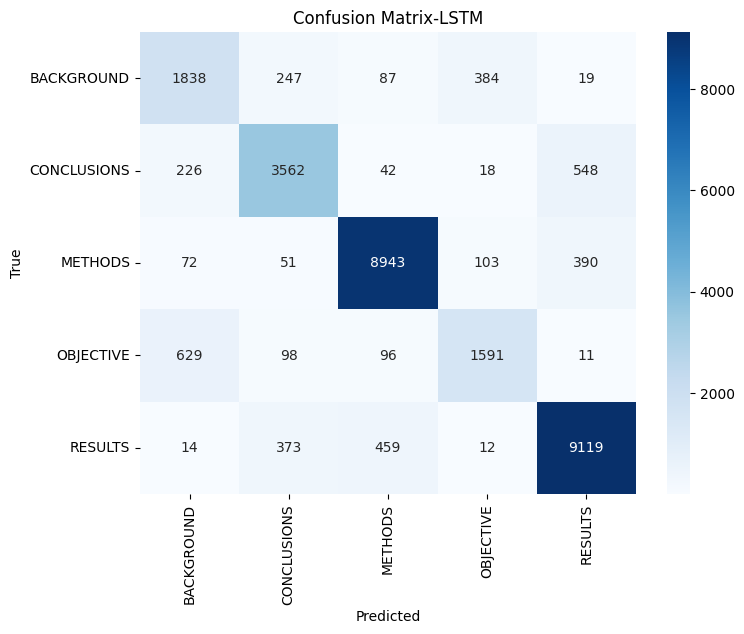

In [21]:
#visualize the Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot = True, fmt="d", xticklabels = label_encoder.classes_,
            yticklabels = label_encoder.classes_, cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix-LSTM")
plt.show()

In [22]:
## Class wise accuracy
class_accuracy = cm.diagonal()/cm.sum(axis=1)
for label, acc in zip(label_encoder.classes_, class_accuracy):
    print(f"{label}: {acc:3f}")

BACKGROUND: 0.713786
CONCLUSIONS: 0.810282
METHODS: 0.935558
OBJECTIVE: 0.656082
RESULTS: 0.914002


In [23]:
# Overall Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(val_true_classes, val_pred_classes)
print("Accuracy:", accuracy)

Accuracy: 0.865927001244297


In [24]:
## Research-Level Evalauation 
from sklearn.metrics import f1_score

macro_f1 = f1_score(val_true_classes, val_pred_classes, average="macro")
weighted_f1 = f1_score(val_true_classes, val_pred_classes, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Macro F1: 0.8092207020220126
Weighted F1: 0.865445479884491


In [25]:
model.save("lstm_text_classifier_safe")

INFO:tensorflow:Assets written to: lstm_text_classifier_safe/assets


INFO:tensorflow:Assets written to: lstm_text_classifier_safe/assets


## Using Bidirectional Model

In [26]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers

In [27]:
train_sentences = train_df["abstract_text"].astype(str).values
val_sentences   = dev_df["abstract_text"].astype(str).values
test_sentences  = test_df["abstract_text"].astype(str).values

train_labels = train_df["target"].values
val_labels   = dev_df["target"].values
test_labels  = test_df["target"].values

In [28]:
label_encoder = LabelEncoder()

train_labels_encoded = label_encoder.fit_transform(train_labels)
val_labels_encoded   = label_encoder.transform(val_labels)
test_labels_encoded  = label_encoder.transform(test_labels)

print(label_encoder.classes_)

['BACKGROUND' 'CONCLUSIONS' 'METHODS' 'OBJECTIVE' 'RESULTS']


In [29]:
max_vocab = 20000

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(train_sentences)

train_sequences = tokenizer.texts_to_sequences(train_sentences)
val_sequences   = tokenizer.texts_to_sequences(val_sentences)
test_sequences  = tokenizer.texts_to_sequences(test_sentences)

In [30]:
max_length = 55

train_padded = pad_sequences(train_sequences, maxlen=max_length, padding="post")
val_padded   = pad_sequences(val_sequences, maxlen=max_length, padding="post")
test_padded  = pad_sequences(test_sequences, maxlen=max_length, padding="post")

In [31]:
train_padded = np.array(train_padded, dtype=np.int32)
val_padded   = np.array(val_padded, dtype=np.int32)
test_padded  = np.array(test_padded, dtype=np.int32)

train_labels_encoded = np.array(train_labels_encoded, dtype=np.int32)
val_labels_encoded   = np.array(val_labels_encoded, dtype=np.int32)
test_labels_encoded  = np.array(test_labels_encoded, dtype=np.int32)

In [32]:
model = tf.keras.Sequential([
    
    layers.Embedding(
        input_dim=max_vocab,
        output_dim=128,
        input_length=max_length
    ),
    
    layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(64)),

    
    layers.Dropout(0.5),
    
    layers.Dense(64, activation="relu"),
    
    layers.Dense(5, activation="softmax")
])


In [33]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

In [44]:
history = model.fit(
    train_padded,
    train_labels_encoded,
    validation_data=(val_padded, val_labels_encoded),
    epochs=5,
    batch_size=256
)

Epoch 1/5
8641/8641 [==============================] - 1097s 127ms/step - loss: 0.2825 - accuracy: 0.8981 - val_loss: 0.3609 - val_accuracy: 0.8689
Epoch 2/5
8641/8641 [==============================] - 1097s 127ms/step - loss: 0.2573 - accuracy: 0.9074 - val_loss: 0.3757 - val_accuracy: 0.8652
Epoch 3/5
8641/8641 [==============================] - 1097s 127ms/step - loss: 0.2365 - accuracy: 0.9152 - val_loss: 0.3880 - val_accuracy: 0.8646
Epoch 4/5
8641/8641 [==============================] - 1097s 127ms/step - loss: 0.2192 - accuracy: 0.9216 - val_loss: 0.4153 - val_accuracy: 0.8623
Epoch 5/5
8641/8641 [==============================] - 1097s 127ms/step - loss: 0.2051 - accuracy: 0.9270 - val_loss: 0.4310 - val_accuracy: 0.8594


In [35]:
# Get Prediction probabilitties
val_pred_probs = model.predict(val_padded)

905/905 [==============================] - 10s 10ms/step


In [36]:
# Convert Predicted Probabilites to class index
val_pred_classes = np.argmax(val_pred_probs, axis = 1)

# Convert Truel labels from one-hot 
val_true_classes = np.argmax(val_labels_onehot, axis =1)

In [37]:
## Classification Report
from sklearn.metrics import classification_report
print(classification_report(val_true_classes,
                            val_pred_classes,
                            target_names = label_encoder.classes_))

              precision    recall  f1-score   support

  BACKGROUND       0.68      0.70      0.69      2575
 CONCLUSIONS       0.85      0.80      0.83      4396
     METHODS       0.92      0.95      0.93      9559
   OBJECTIVE       0.78      0.66      0.71      2425
     RESULTS       0.90      0.92      0.91      9977

    accuracy                           0.87     28932
   macro avg       0.83      0.81      0.81     28932
weighted avg       0.87      0.87      0.87     28932



In [38]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_true_classes, val_pred_classes)
print(cm)

[[1800  238  155  367   15]
 [ 199 3532   47   13  605]
 [  48   34 9062   67  348]
 [ 597   95  131 1589   13]
 [  11  257  494    5 9210]]


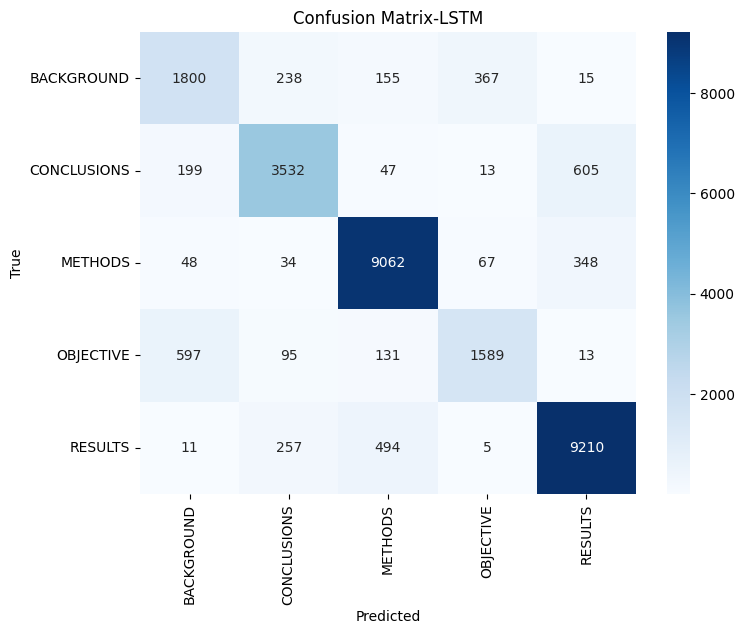

In [39]:
#visualize the Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot = True, fmt="d", xticklabels = label_encoder.classes_,
            yticklabels = label_encoder.classes_, cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix-LSTM")
plt.show()

In [40]:
## Class wise accuracy
class_accuracy = cm.diagonal()/cm.sum(axis=1)
for label, acc in zip(label_encoder.classes_, class_accuracy):
    print(f"{label}: {acc:3f}")

BACKGROUND: 0.699029
CONCLUSIONS: 0.803458
METHODS: 0.948007
OBJECTIVE: 0.655258
RESULTS: 0.923123


In [41]:
# Overall Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(val_true_classes, val_pred_classes)
print("Accuracy:", accuracy)

Accuracy: 0.8707659339140053


In [42]:
## Research-Level Evalauation 
from sklearn.metrics import f1_score

macro_f1 = f1_score(val_true_classes, val_pred_classes, average="macro")
weighted_f1 = f1_score(val_true_classes, val_pred_classes, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Macro F1: 0.8142379886926573
Weighted F1: 0.8692700505631061


In [43]:
model.save("Bilstm_text_classifier_safe")

INFO:tensorflow:Assets written to: Bilstm_text_classifier_safe/assets


INFO:tensorflow:Assets written to: Bilstm_text_classifier_safe/assets
